<a href="https://colab.research.google.com/github/diptanshusb-dotcom/ML_Lab/blob/main/Diptanshu(practical1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   Student Name: Diptanshu .s.bagul
*   Div: CSE — A
*   Practical Batch: A1
*   Roll No: 13
*   Date: 02/09/2026
*   Practical Name:Implement simple and multiple linear regression using Numpy and using Scikit-learn. Plot regression lines and residuals. Compute RMSE and R2 values.

In [ ]:
#import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#create the dataset
data ={
    "Study_hours" : [1,2,3,4,5,6,7,8,9,10] ,
    "Attendence" : [60,85,70,95,65,80,90,75,88,72] ,
    "Marks" : [32,42,47,58,61,67,76,79,88,91]
}

#Convert dicr into DataFrame
df = pd.DataFrame(data)
print(df)


   Study_hours  Attendence  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61
5            6          80     67
6            7          90     76
7            8          75     79
8            9          88     88
9           10          72     91


In [ ]:
# EDA and Preprocessing
print("\nFirst Five Rows:\n", df.head())

print("\nShape of Dataset:\n", df.shape)

print("\nInformation:")
df.info()

print("\nStatistical Analysis:\n", df.describe())

print("\nCheck for Null values:\n", df.isnull().sum())

print("\nDuplicate Values Count:\n", df.duplicated().sum())

print("\nDataset after removing duplicates:\n", df.drop_duplicates())


First Five Rows:
    Study_hours  Attendence  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61

Shape of Dataset:
 (10, 3)

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_hours  10 non-null     int64
 1   Attendence   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes

Statistical Analysis:
        Study_hours  Attendence      Marks
count     10.00000   10.000000  10.000000
mean       5.50000   78.000000  64.100000
std        3.02765   11.489125  19.790289
min        1.00000   60.000000  32.000000
25%        3.25000   70.500000  49.750000
50%        5.50000   77.500000  64.000000
75%        7.75000   87.250000  78.250000
max       10.00000   95.000000 

In [ ]:
#Data Visualization

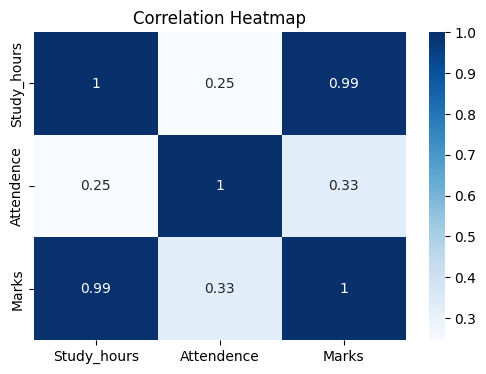

In [ ]:
#Correlation Heatmap
import seaborn as sns
df_corr = df.corr()
plt.figure(figsize=(6,4))
sns.heatmap(df_corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# A] Simple Linear Regression by Using Sckit-learn

In [ ]:
# Feature Selection
x = df[['Study_hours']]
y = df[['Marks']]

In [ ]:
#Split dataset into training and testing set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(x_test)

   Study_hours
8            9
1            2
5            6


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
#Train the model
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(y_pred)

[[86.55445545]
 [41.22772277]
 [67.12871287]]


In [ ]:
#Print Equation

print('Intercept: ',model.intercept_)
print('Slop : ',model.coef_[0])

Intercept:  [28.27722772]
Slop :  [6.47524752]


In [ ]:
#SLR Equation
# Marks = (6.48 * Study_Hours)+28.27

#EVALUATION
from sklearn.metrics import root_mean_squared_error, r2_score
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Root Mean Squared Error: ', round(rmse,3))
print('R2 Score: ', round(r2,2))

Root Mean Squared Error:  0.949
R2 Score:  1.0


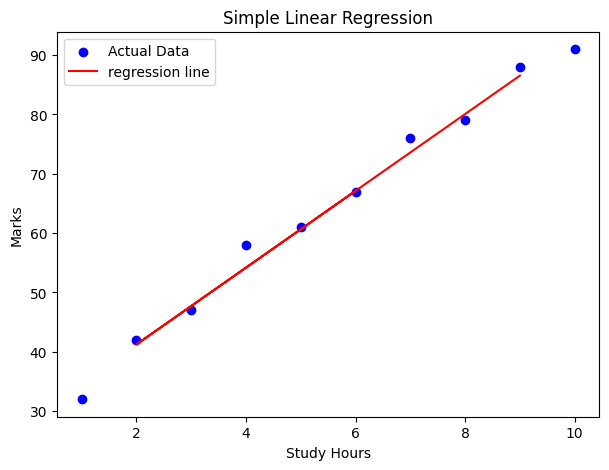

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(x,y,color='BLUE',label='Actual Data')

plt.plot(x_test,y_pred,color='red',label='regression line')

plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

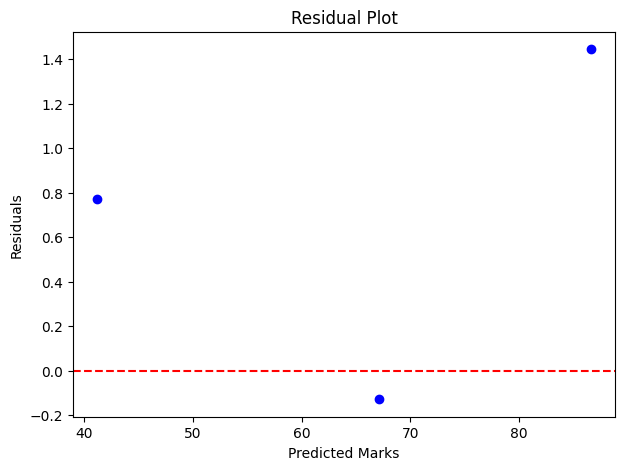

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


In [ ]:
#Independent Variable (Features)
x = df['Study_hours'].values

#Dependent Variable (Target)
y = df['Marks'].values

x_mean = np.mean(x)
y_mean = np.mean(y)

#Calculate mean
m = np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)
b = y_mean - m*x_mean

print('Slope (m):', m)
print('Intercept (c):', b)

#Prediction
y_pred = m*x + b
print(y_pred)

Slope (m): 6.503030303030303
Intercept (c): 28.33333333333333
[34.83636364 41.33939394 47.84242424 54.34545455 60.84848485 67.35151515
 73.85454545 80.35757576 86.86060606 93.36363636]


In [ ]:
#Feature Selection
x = df[['Study_hours', 'Attendence']] #independent var
y = df['Marks'] #dependent var

#split dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(x_test)


   Study_hours  Attendence
8            9          88
1            2          85
5            6          80


In [ ]:
#MODEL BUILDING
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(y_pred)

[88.08653885 43.59718321 67.84336712]


In [ ]:
#MODEL PARAMETERS
print('Intercept:',model.intercept_)
print("Coefficients:")

coeff = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
})

print(coeff)


Intercept: 16.14458419831481
Coefficients:
       Feature  Coefficient
0  Study_hours     6.280539
1   Attendence     0.175194


Metrics Values of MLR:
RMSE 1.04
R2 Score 1.0


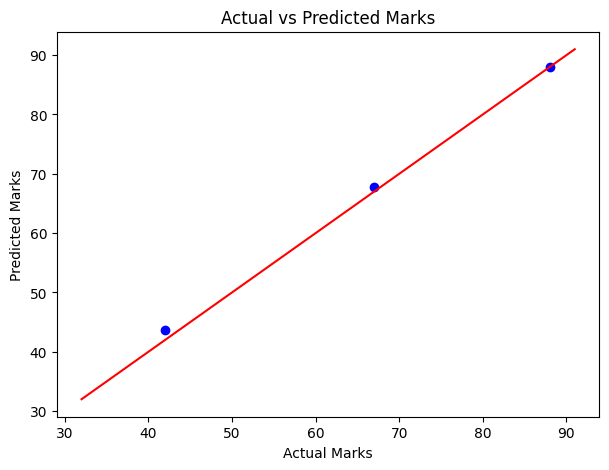

In [ ]:
#Evauation Metrics
print('Metrics Values of MLR:')
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('RMSE', round(rmse,2))
print('R2 Score', round(r2,2))

#Actual vs Predicted Plot
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, color='blue')

#Perfect Prediction Line
plt.plot([y.min(),y.max()],[y.min(),y.max()],color='red')

plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Actual vs Predicted Marks')
plt.show()



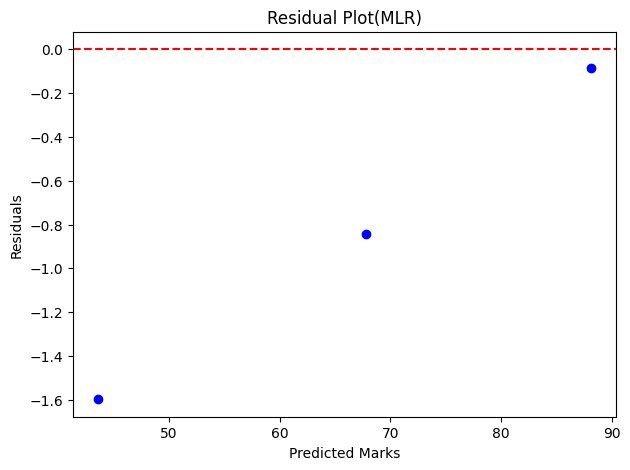

In [ ]:
#Residual Plot

residuals = y_test - y_pred #calculate residual

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot(MLR)')
plt.show()